In [1]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>')) # change code & markdown block width
display(HTML('<style>.output_result { max-width:100% !important; }</style>')) # change output cells width

# Set global font properties
import matplotlib as mpl
mpl.rc('font', family='sans-serif', size=16)              # Base font family and size
mpl.rc('axes', titlesize=20, titleweight='bold')          # Subplot titles
mpl.rc('figure', titlesize=22, titleweight='bold')        # Suptitles

**Objectives:** Spectroscopic fitting with two Gaussians for each line using AI.

In [2]:
from parameters import Parameter, SpectralWindow, EmissionLine, GaussianSuperposition, ParameterMapping

# Create a dictionary of Channels (SpectralWindow)
channels = { ch_name : SpectralWindow(ch_name, emlines=[f'{ch_name}.{lname}' for lname in ('A',)], x_lims=(0, 1) )
    for ch_name in ['I', 'II', 'III', 'IV'] }
print('Channels', channels)

GpL = 2; # Number of Gaussian components to fit per spectral line

# Different from 'emline" variable which corresponds to observed emission line data
# The following parameters are defined automatically:
# key = (ln_name, parname, component) for each emline, each component, and for parname in {'amp', 'mu', 'sigma'}
emlines = { lname: EmissionLine(
                    lname, 
                    ch.name, 
                    GpL, 
                    par_lims={ 'amp': (0, 10) },
                    mu0=(ln_idx+1)/(len(ch.lines)+1) # shift for line in channel
                )
                for ch in channels.values() 
                for ln_idx, lname in enumerate(ch.lines) # (!) Note that the first for loop is evaluated first
            }
print('Emission Lines:', emlines)

# Define extra parameters that will be used to constrain the Gaussian line parameters
extra_parameters = [
    # Line-of-sight projection of velocity at pixel:
    # key = ('velocity', comp)
    Parameter(key=('velocity', 0), lims=(-0.3, 0.3)),
    Parameter(key=('velocity', 1), lims=(-0.3, 0.3)),
    
    # Dispersion of velocities at pixel:
    # key = ('dispersion', comp)
    Parameter(key=('dispersion', 0), lims=(0.01, 0.1)),
    Parameter(key=('dispersion', 1), lims=(0.01, 0.1)),
]

# Combine all parameters
all_parameters = [p for ln in emlines.values() for p in ln.parameters] + extra_parameters

## Constraints:
# A dictionary of form { pattern: fun(par_dict, *key) }.
# Each (tied) parameter whose `key` matches `pattern` shall be assigned the result of evaluating `fun`.
# - The tuple `pattern` = (p_1, p_2, ..., p_n) has elements which are an exact value or the `None` wildcard;
# This wildcard matches any key. For instance, the pattern `(None, 'mu', None)` matches `('Halpha', 'mu', 0)`, `('OIII', 'mu', 1)`, etc.
# - The method `fun` takes in a dictionary of already assigned parameters, `par_dict`, and the `key` corresponding to the tied parameter to be assigned.
# Tied parameters should depend only on free parameters, otherwise behaviour is not guaranteed.

# We define constraints on velocity and dispersion.
# For this we can define the following functions:

# Corresponding constraint `fun`
def velocity_constraint(par_dict, *key):
    lname, parname, comp = key
    ln = emlines[lname]
    return ln.mu0 + par_dict['velocity', comp]

# Corresponding constraint `fun`
def dispersion_constraint(par_dict, *key):
    lname, parname, comp = key
    return par_dict['dispersion', comp]

# We now define the constraint dictionary using wildcards:
constraints = {
    (None, 'mu', None): velocity_constraint,
    (None, 'sigma', None): dispersion_constraint,
}
# Note that we could do the following instead, if we did not want to use wildcards:
# constraints = {
#     **{
#     (ln.name, 'mu', comp): velocity_constraint for ln in emlines for comp in [0, 1]
#     },
#     **{
#     (ln.name, 'sigma', comp): dispersion_constraint for ln in emlines for comp in [0, 1]
#     },
# }

# The ParameterMapping instance encodes how each parameter in network output is mapped onto each component in a spectral line
# Constraints are applied at this step to determine the non-free parameters of each Gaussian.
# Parameters are also normalized when feeding into the network, and denormalized after unpack.
parameter_mapping = ParameterMapping(all_parameters, constraints)

# The GaussianSuperposition instance reconstructs the spectral signal from the Gaussian parameters of each line
gaussian_model = GaussianSuperposition(emlines, channels, parameter_mapping)

print('Gaussian model:')
print('- Free parameters:', list(parameter_mapping.free_params))
print('- Tied parameters:', list(parameter_mapping.tied_params))
print('- Constraints:', parameter_mapping.constraints)


Channels {'I': SpectralWindow(name=I, x_lims=(0, 1), lines=['I.A']), 'II': SpectralWindow(name=II, x_lims=(0, 1), lines=['II.A']), 'III': SpectralWindow(name=III, x_lims=(0, 1), lines=['III.A']), 'IV': SpectralWindow(name=IV, x_lims=(0, 1), lines=['IV.A'])}
Emission Lines: {'I.A': EmissionLine(name=I.A, channel=I, ncomp=2), 'II.A': EmissionLine(name=II.A, channel=II, ncomp=2), 'III.A': EmissionLine(name=III.A, channel=III, ncomp=2), 'IV.A': EmissionLine(name=IV.A, channel=IV, ncomp=2)}
Gaussian model:
- Free parameters: [Parameter(key=('I.A', 'amp', 0), lims=(0, 10)), Parameter(key=('I.A', 'amp', 1), lims=(0, 10)), Parameter(key=('II.A', 'amp', 0), lims=(0, 10)), Parameter(key=('II.A', 'amp', 1), lims=(0, 10)), Parameter(key=('III.A', 'amp', 0), lims=(0, 10)), Parameter(key=('III.A', 'amp', 1), lims=(0, 10)), Parameter(key=('IV.A', 'amp', 0), lims=(0, 10)), Parameter(key=('IV.A', 'amp', 1), lims=(0, 10)), Parameter(key=('velocity', 0), lims=(-0.3, 0.3)), Parameter(key=('velocity', 1), 

In [3]:
# N = Number of artificial training samples (i.e. independent spectra) to generate for training the network
# C = Number of channels (each channel is a window of spectral data containing at least one spectral line)
# D = Number of datapoints in each channel (~ spectral resolution)
N = 12800
C = len(channels)
D = 100

# The neural network can process multiple spectra at a time. The number of spectra processed simultaneously is called 'batch_size'
# The network input has shape (batch_size < N, channels = C, datapoints = D)
# The network output has shape (batch_size < N, total_free_parameters), where the total_free_parameter dimension is a vector with all the free parameters in the fitting model

L = len(emlines) # total number of lines
# G = GpL * L # total number of gaussians


## Artificial dataset

#### **Step 1:** Randomly generate free parameters.

#### **Step 2:** Sort the two Gaussians components ($\mu_1 < \mu_2$)
Sorting the two Gaussians is necessary to ensure non-degeneracy of inverse problem!

In this way our network learns how to output sorted gaussians.

Another option is to have a loss symmetric wrt the gaussian ordering. Then we don't care.

#### **Step 3:** Convert to pytorch

#### **Step 4:** Create spectroscopic data for model training.

In [4]:
import numpy as np

P = len(parameter_mapping.free_params) # number of free parameters in model

## Step 1 ##
# Randomly sample free parameters in our model

# Random number generator
rng = np.random.default_rng()

# Sample whole space between (min, max) = par.lims
par_dict = {
    par.key: rng.uniform(*par.lims, size=N) 
    for par in parameter_mapping.free_params
}

## Step 2 ##
# Ensure that velocity of component 0 < velocity of component 1. 
# so that leftmost Gaussians are index 0.

keys = [('velocity', 0), ('velocity', 1)]
vels = [par_dict[key] for key in keys]

# Sort the Gaussian components for each sample
# (!) Note that in this step we are assuming that param.lims is the same for each velocity component
# Otherwise we would need to use a rejection sampling strategy
vels = np.sort(vels, axis=0)

# Update par_dict with sorted values
for i, key in enumerate(keys):
    par_dict[key] = vels[i]


## Step 3 ##

import torch

# Let us set up torch to use double (float64) by default:
torch.set_default_dtype(torch.float64)

# Convert data to PyTorch tensors
to_tensor = lambda arr: torch.tensor(arr, dtype=torch.float64)

# Updates the parameter dictionary to tensors
pars_dict = {
    key : to_tensor(val) for (key, val) in par_dict.items()
}

# Generate Gaussian signals

# Shape parameters into a tensor for use in the neural network
# Input dictionary should have sampled all the free parameters
pars = parameter_mapping.pack_tensor(pars_dict)

# Defensive programming: Ensure implementation of tensor packing / unpacking is giving correct results
# Delete this in final code
unpacked_dict = parameter_mapping.unpack_tensor(pars)
free_keys = {par.key for par in parameter_mapping.free_params}
unpacked_dict = {key: val for key, val in unpacked_dict.items() if key in free_keys}
assert pars_dict.keys() == unpacked_dict.keys(), f'Keys mismatch: {pars_dict.keys()} != {unpacked_dict.keys()}'
assert all(torch.allclose(pars_dict[key], unpacked_dict[key]) for key in unpacked_dict.keys()), f'Parameter tensor packing issue! {
    [key for key in unpacked_dict.keys() if not torch.allclose(pars_dict[key], unpacked_dict[key])]
}'
pars_dict = parameter_mapping.unpack_tensor(pars)

# Setup domain of signal
x = np.linspace(0, 1, D, dtype=np.float64)
x = to_tensor(x)
x = x.expand(1, C, D)

# Calculate the Gaussian components: use wavelength
y = gaussian_model.components(x, pars) # (N, C, LpC, KpL, D)

# Calculate superposed spectrum: use wavelength
z = gaussian_model(x, pars) # output shape (N, C, D)

assert z.shape == (N, C, D), f'Spectrum is not in expected shape! (shape = {z.shape}, expected = {(N, C, D)})'

# Add optional noise
w_std = 0.1e-2 * np.ones((N, C, D)) # to simplify, we use uniform amplitude across channels
w = rng.normal(scale=w_std) # normal distribution of noise, independently sampled for each wavelength
w = to_tensor(w)

z = z + w
# snr = z / noise_std * np.max(noise_std)

Sample data plot:

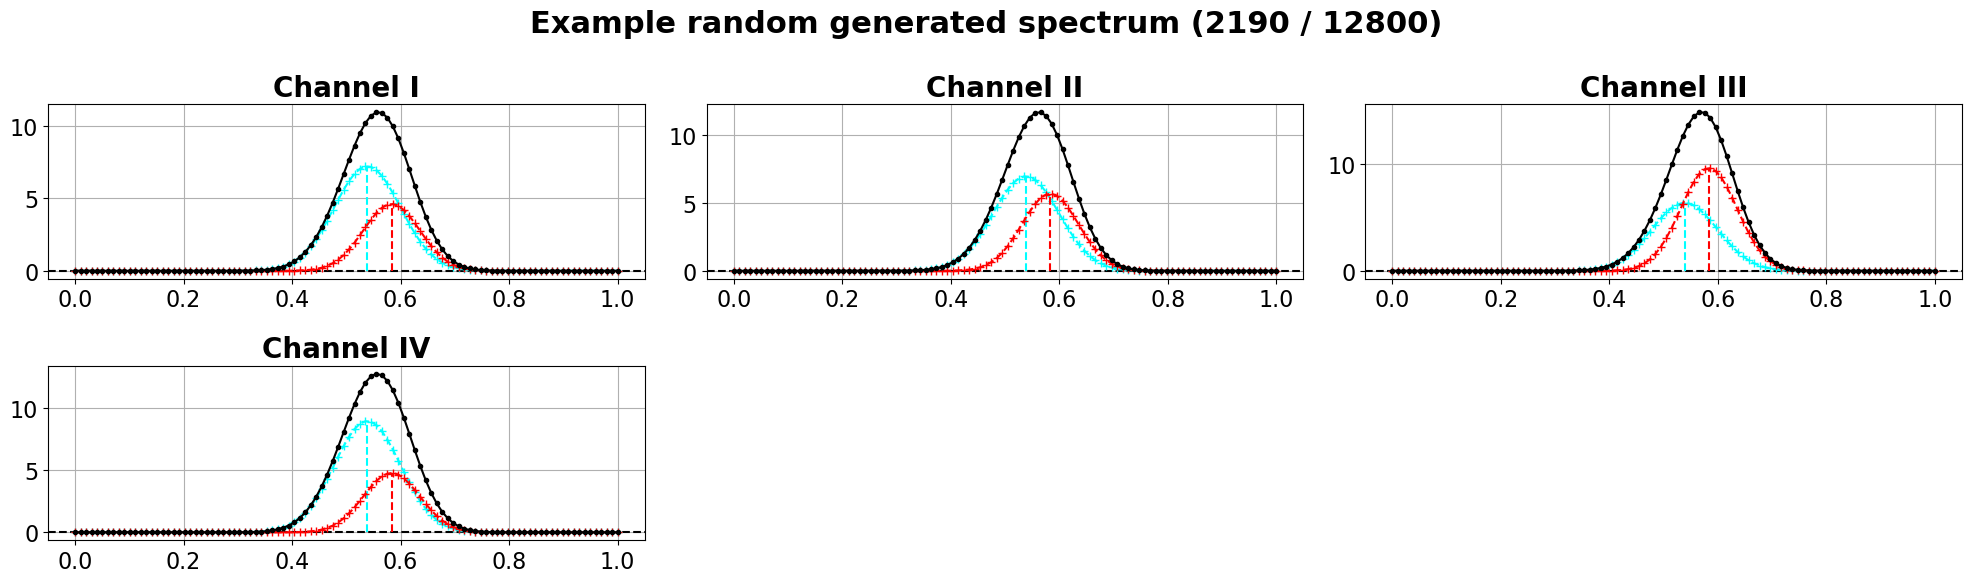

EXAMPLE DATA (2190 / 12800):

* Velocities:
    [0.03871159518164602, 0.08343249811269327]
* Dispersion:
    [0.06112587800793993, 0.0519325334168445]
* Amplitudes:
    Channel 0: [7.196019988197737, 4.598728836230032],
    Channel 1: [6.9595676167972345, 5.679121708951593],
    Channel 2: [6.367189386059913, 9.631565072099548],
    Channel 3: [8.972979757746597, 4.788180359447641],


In [5]:
from matplotlib import pyplot as plt

sample = rng.integers(N)


plt.figure(figsize=(20, 6))
plt.suptitle(f'Example random generated spectrum ({sample+1} / {N})')
for ch_idx, ch in enumerate(channels.values()):
  ax = plt.subplot((C+2)//3, 3, ch_idx+1)
  ax.set_title(f'Channel {ch.name}')
  # ax.plot(x, snr[sample, ch_idx], color='grey')
  # ax.plot(x[0, ch_idx], z[sample, ch_idx], color='black', marker='o')  
  ax.errorbar(x[0, ch_idx], z[sample, ch_idx], yerr=w_std[sample, ch_idx], color='black', marker='.')
  ax.axhline(0, 0, 1, color='black', linestyle='--')
  for line_idx, line_name in enumerate(ch.lines):
    for comp_idx, color in zip(range(GpL), ['cyan', 'red']):
      ax.plot(x[0, ch_idx], y[sample, ch_idx, line_idx, comp_idx], color=color, linestyle='dashed', marker='+')
      ax.vlines(pars_dict[line_name, 'mu', comp_idx][sample], 0, pars_dict[line_name, 'amp', comp_idx][sample], colors=color, linestyles='--')
  ax.grid(True)

# plt.xlabel('x')
# plt.ylabel('y')
plt.tight_layout()
plt.show()

print(f'EXAMPLE DATA ({sample+1} / {N}):\n')
print('* Velocities:', f'    {[par_dict['velocity', c][sample] for c in (0, 1)]}', sep='\n')
print('* Dispersion:', f'    {[par_dict['dispersion', c][sample] for c in (0, 1)]}', sep='\n')
print('* Amplitudes:', *(f'    Channel {i}: {[par_dict[ln, 'amp', c][sample] for c in (0, 1)]},' for i, ln in enumerate(emlines)), sep='\n')
# print('Means:', *(f'    Channel -: {val},' for i, val in enumerate(zip(*mu[sample]))), sep='\n')
# print('Stdevs:', *(f'    Channel {i}: {val},' for i, val in enumerate(zip(*sigma[sample]))), sep='\n')

**Step 2.** Define the neural network model.

In [6]:
import torch.nn.functional as F

## Minimization Objectives ##
# We use a weighted average of two loss functions:
# Parameter loss: L2 loss on normalized model parameters
# Signal loss: L2 loss on signals

def parameter_loss(output: torch.Tensor, 
                   target: torch.Tensor, 
                   reduction: str = 'mean') -> torch.Tensor:
    '''
    Computes MSE loss over the last dimension (parameters), and optionally 
    reduces over the batch dimension based on `reduction`.

    Args:
        output (torch.Tensor): Shape (N, P).
        target (torch.Tensor): Shape (N, P).
        reduction (str): One of 'none', 'mean', or 'sum'.
            - 'none': Returns loss for each item in the batch.
            - 'mean': Averages loss across the batch.
            - 'sum': Sums loss across the batch.

    Returns:
        torch.Tensor: Loss value (scalar if reduction is 'mean' or 'sum'; 
                      otherwise size (N,) if 'none').
    '''
    # Always compute MSE with no reduction, then average across parameter dimension P
    loss = F.mse_loss(output, target, reduction='none').mean(dim=-1)  # shape: (N,)

    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    elif reduction == 'none':
        return loss
    else:
        raise ValueError(f'Invalid reduction mode "{reduction}". '
                         'Use "none", "mean", or "sum".')

def signal_loss(output: torch.Tensor, 
                target: torch.Tensor, 
                x: torch.Tensor, 
                reduction: str = 'mean',
                lims : float = (z.min(), z.max())
                ) -> torch.Tensor:
    '''
    Computes MSE loss for each entry in the batch (N), 
    and optionally reduces over the batch dimension based on `reduction`.

    Signal is normalized by lims.

    Args:
        output (torch.Tensor): Model parameters of shape (N, P).
        target (torch.Tensor): Target parameters of shape (N, P).
        x (torch.Tensor): Input to the Gaussian model, shape (1, C, D). 
        reduction (str): One of 'none', 'mean', or 'sum'.
            - 'none': Returns loss for each item in the batch.
            - 'mean': Averages loss across the batch.
            - 'sum': Sums loss across the batch.

    Returns:
        torch.Tensor: Loss value (scalar if reduction is 'mean' or 'sum'; 
                      otherwise size (N,) if 'none').
    '''
    z_out = gaussian_model(x, output)  # Shape (N, C, D)
    z_tar = gaussian_model(x, target)  # Shape (N, C, D)

    # Always compute MSE with no reduction, then average across data dimension D
    loss = F.mse_loss(z_out, z_tar, reduction='none').mean(dim=(1,2))  # shape: (N,)

    # Normalize the loss with respect to the maximum value:
    min, max = lims
    loss = loss / (max - min)

    if reduction == 'mean':
        return loss.mean()  # Average across batch (N)
    elif reduction == 'sum':
        return loss.sum()   # Sum across batch (N)
    elif reduction == 'none':
        return loss         # Keep per-sample losses
    else:
        raise ValueError(f'Invalid reduction mode "{reduction}". '
                         'Use "none", "mean", or "sum".')
    
def criterion(output, target, x, weights=(0.01, 1), reduction = 'mean'):
    '''
    output, target: parameter tensors of network (N, P)
    '''
    # Normalize weights
    w_sum = sum(weights)
    weights = tuple(w / w_sum for w in weights)

    l_signal = signal_loss(output, target, x, reduction=reduction)

    l_param = parameter_loss(output, target, reduction=reduction)

    return l_signal*weights[0] + l_param*weights[1]


### Optimization stage criteria

from parameters import Pattern

# L2 Regularization of negative values
def negative_l2_reg(out, mask, weight=1):
  neg = torch.clamp(out * mask, max=0) # take negative amplitudes
  return weight * torch.sum(neg**2) # compute the sum of squares


**Next steps:** Use the generated dataset and train the model to learn the Gaussian parameters from the spectroscopic signal.

In [7]:
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, Subset, DataLoader

from models import CoordGaussNet, FirstGaussNet
from optim import EarlyStopping

# Choose model
# We are using the Coordinate Convolution model
# However, we are currently assuming a linear partition of the wavelengths (which is not strictly the case)
# We can also test Conv1d groups = C (not currently possible bcs CoordConv adds 1 channel)
model = CoordGaussNet(C, P, D)
print('Model architecture', f'({sum(p.numel() for p in model.parameters())} parameters):')
print(model)

# Determine if GPU (CUDA) is available and move data to device
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device setup: {device}.')

x = x.to(device)
z = z.to(device)
pars = pars.to(device)
model.to(device)

# Create the training and test datasets
dataset = TensorDataset(z, pars)
split = (N*8)//10
train_data = Subset(dataset, range(0, split))
test_data = Subset(dataset, range(split, N))

# Create a DataLoader
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

# Choose optimizer configuration
optimizer = optim.Adam(model.parameters(), lr=0.5e-3, weight_decay=1e-3, amsgrad=True)

# LR Scheduler reduces the learning rate when the training plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.3, patience=10, threshold=3e-3, verbose=True)

# Early stopping
early_stopping = EarlyStopping(patience=25, min_delta=1e-4, mode='min')  # Mode 'min' for minimizing loss

# Save errors for plotting
history = {
    'epochs': [],
    'train_loss': [],
    'test_loss': []
}

# Evaluate error on untrained model (epoch 0)
with torch.no_grad():

    model.eval()  # Set model to evaluation mode

    train_loss = 0.0
    for signal, params in train_loader:
        output = model(signal)
        train_loss += criterion(output, params, x) * len(output)
    train_loss /= len(train_data)

    test_loss = 0.0
    for signal, params in test_loader:
        output = model(signal)
        test_loss += criterion(output, params, x) * len(output)
    test_loss /= len(test_data)
    
    history['epochs'].append(0)
    history['train_loss'].append(train_loss.item())
    history['test_loss'].append(test_loss.item())

    print(f'Loss at epoch 0: Training {train_loss.item():.4f} | Test {test_loss:.4f}')

Model architecture (1370092 parameters):
CoordGaussNet(
  (conv1a): CoordConv1d(4, 32, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn1a): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): CoordConv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn1b): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2a): CoordConv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn2a): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): CoordConv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn2b): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, st

c:\Users\chris\.conda\envs\torch\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loss at epoch 0: Training 0.4226 | Test 0.4214


In [8]:
# Training loop
start_epoch = history['epochs'][-1] + 1
train_duration = 200
history_skip = 1
for epoch in range(start_epoch, start_epoch + train_duration):
  model.train()
  train_loss = 0.0
  for signal, params in train_loader:
    optimizer.zero_grad()
    output = model(signal)
    loss = criterion(output, params, x)
    loss.backward()
    optimizer.step()
    train_loss += loss.item() * len(output)
  train_loss /= len(train_data)

  # Evaluate the model on the test set every few epochs
  if epoch % history_skip == 0:
    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():
      for signal, params in test_loader:
        output = model(signal)
        loss = criterion(output, params, x)
        test_loss += loss.item() * len(output)
    test_loss /= len(test_data)

    # Save metadata to history dict
    history['epochs'].append(epoch)
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)

    print(f'[Loss at epoch {epoch:03d} / {start_epoch + train_duration - 1}], Training: {train_loss:.6f}, Test: {test_loss:.6f}. LR({scheduler.get_last_lr()[0]:.2e})')

    # Check for early stopping
    early_stopping(test_loss)
    if early_stopping.early_stop:
        print(f'Early stopping at epoch {epoch}...')
        break

    # Update learning rate
    scheduler.step(test_loss)

print('Training Complete!')


from datetime import datetime

timestamp = datetime.today().strftime('%Y-%m-%d_%H-%M-%S')
path = f'./models/gnet_{timestamp}.pt'
save_model = True
if save_model:
  torch.save(model.state_dict(), path)
  print(f'The model has been saved to path {path}')

[Loss at epoch 001 / 200], Training: 0.054385, Test: 0.034495. LR(5.00e-04)
[Loss at epoch 002 / 200], Training: 0.018886, Test: 0.015185. LR(5.00e-04)
[Loss at epoch 003 / 200], Training: 0.014065, Test: 0.017081. LR(5.00e-04)
[Loss at epoch 004 / 200], Training: 0.011794, Test: 0.015195. LR(5.00e-04)
[Loss at epoch 005 / 200], Training: 0.010916, Test: 0.015456. LR(5.00e-04)
[Loss at epoch 006 / 200], Training: 0.009773, Test: 0.011531. LR(5.00e-04)
[Loss at epoch 007 / 200], Training: 0.009358, Test: 0.013795. LR(5.00e-04)
[Loss at epoch 008 / 200], Training: 0.008711, Test: 0.013691. LR(5.00e-04)
[Loss at epoch 009 / 200], Training: 0.008539, Test: 0.011184. LR(5.00e-04)
[Loss at epoch 010 / 200], Training: 0.008159, Test: 0.010706. LR(5.00e-04)
[Loss at epoch 011 / 200], Training: 0.008040, Test: 0.008899. LR(5.00e-04)
[Loss at epoch 012 / 200], Training: 0.007635, Test: 0.009224. LR(5.00e-04)
[Loss at epoch 013 / 200], Training: 0.007631, Test: 0.011386. LR(5.00e-04)
[Loss at epo

#### Plot the evolution of the error throughout training

Summary:
  Epochs: 113
  Min train loss: 1.764e-03
  Min test loss: 2.312e-03


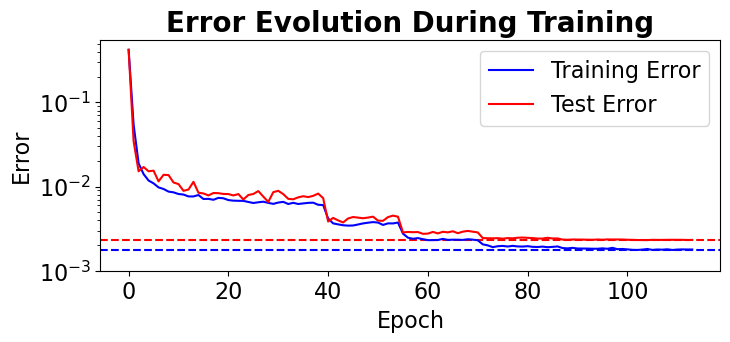

In [9]:
min_train = min(*history['train_loss'])
min_test = min(*history['test_loss'])

print('Summary:', f'  Epochs: {max(*history['epochs'])}', f'  Min train loss: {min_train:.3e}', f'  Min test loss: {min_test:.3e}',sep='\n')

# "nearest power of 10 less than x"
floor10 = lambda x : 10**(np.log10(x)//1)

plt.figure(figsize=(8, 3))
# plt.axhline(min(*history['train_loss'], *history['test_loss']), color='k')
plt.axhline(min_train, color='b', linestyle='--')
plt.axhline(min_test, color='r', linestyle='--')
plt.plot(history['epochs'], history['train_loss'], label="Training Error", color = 'b')
plt.plot(history['epochs'], history['test_loss'], label="Test Error", color = 'r')
plt.yscale('log')
plt.ylim(floor10(min(min_train, min_test)), None)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Error Evolution During Training")
plt.legend()
plt.show()

In [10]:
if False:
    model_data = torch.load(path, weights_only=True)
    model.load_state_dict(model_data)
    model.eval()

Plot a sample of spectra, comparing the generated data and the output of the network.

Reconstructed vs True Spectrum 1 / 5     (MSE[P] = 5.03e-04 / MSE[Z] = 3.77e-02)
* Velocities:
    Pred: [tensor(-0.2396, device='cuda:0'), tensor(0.0412, device='cuda:0')]
    True: [tensor(-0.2404, device='cuda:0'), tensor(0.0530, device='cuda:0')]
* Dispersion:
    Pred: [tensor(0.0902, device='cuda:0'), tensor(0.0121, device='cuda:0')]
    True: [tensor(0.0907, device='cuda:0'), tensor(0.0141, device='cuda:0')]
* Amplitudes:
    Line I.A:
      Pred [tensor(6.8648, device='cuda:0'), tensor(8.5185, device='cuda:0')],
      True [tensor(6.5573, device='cuda:0'), tensor(8.7507, device='cuda:0')],
    Line II.A:
      Pred [tensor(7.3282, device='cuda:0'), tensor(8.8819, device='cuda:0')],
      True [tensor(7.2687, device='cuda:0'), tensor(8.9917, device='cuda:0')],
    Line III.A:
      Pred [tensor(6.8952, device='cuda:0'), tensor(8.8835, device='cuda:0')],
      True [tensor(6.6403, device='cuda:0'), tensor(9.2908, device='cuda:0')],
    Line IV.A:
      Pred [tensor(1.5703, device

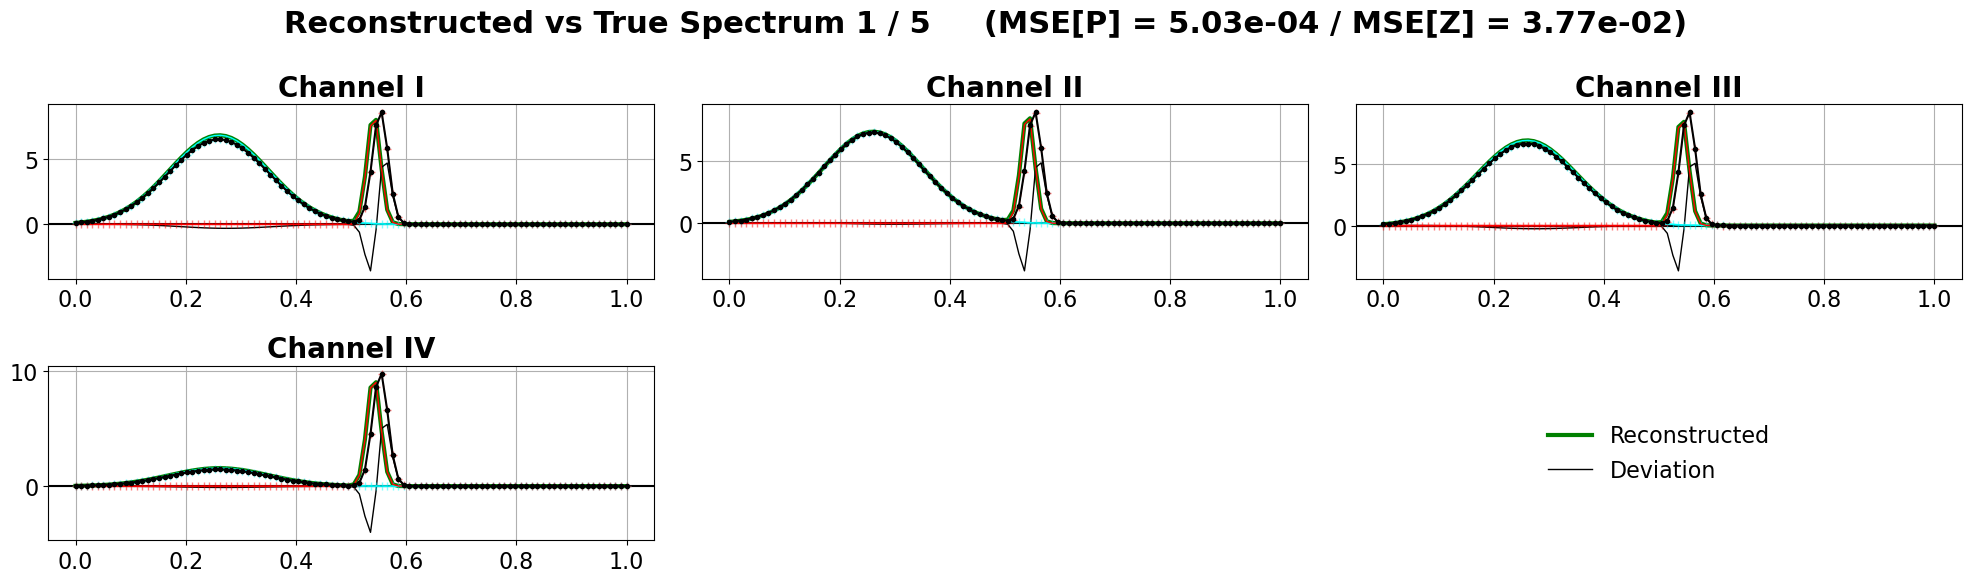

Reconstructed vs True Spectrum 2 / 5     (MSE[P] = 3.40e-03 / MSE[Z] = 9.84e-04)
* Velocities:
    Pred: [tensor(0.2197, device='cuda:0'), tensor(0.2514, device='cuda:0')]
    True: [tensor(0.2226, device='cuda:0'), tensor(0.2478, device='cuda:0')]
* Dispersion:
    Pred: [tensor(0.0874, device='cuda:0'), tensor(0.0872, device='cuda:0')]
    True: [tensor(0.0911, device='cuda:0'), tensor(0.0841, device='cuda:0')]
* Amplitudes:
    Line I.A:
      Pred [tensor(2.9937, device='cuda:0'), tensor(2.9747, device='cuda:0')],
      True [tensor(2.5809, device='cuda:0'), tensor(3.5386, device='cuda:0')],
    Line II.A:
      Pred [tensor(5.8175, device='cuda:0'), tensor(6.8565, device='cuda:0')],
      True [tensor(5.8998, device='cuda:0'), tensor(6.2556, device='cuda:0')],
    Line III.A:
      Pred [tensor(8.1936, device='cuda:0'), tensor(2.9522, device='cuda:0')],
      True [tensor(9.2410, device='cuda:0'), tensor(1.6185, device='cuda:0')],
    Line IV.A:
      Pred [tensor(1.3446, device='

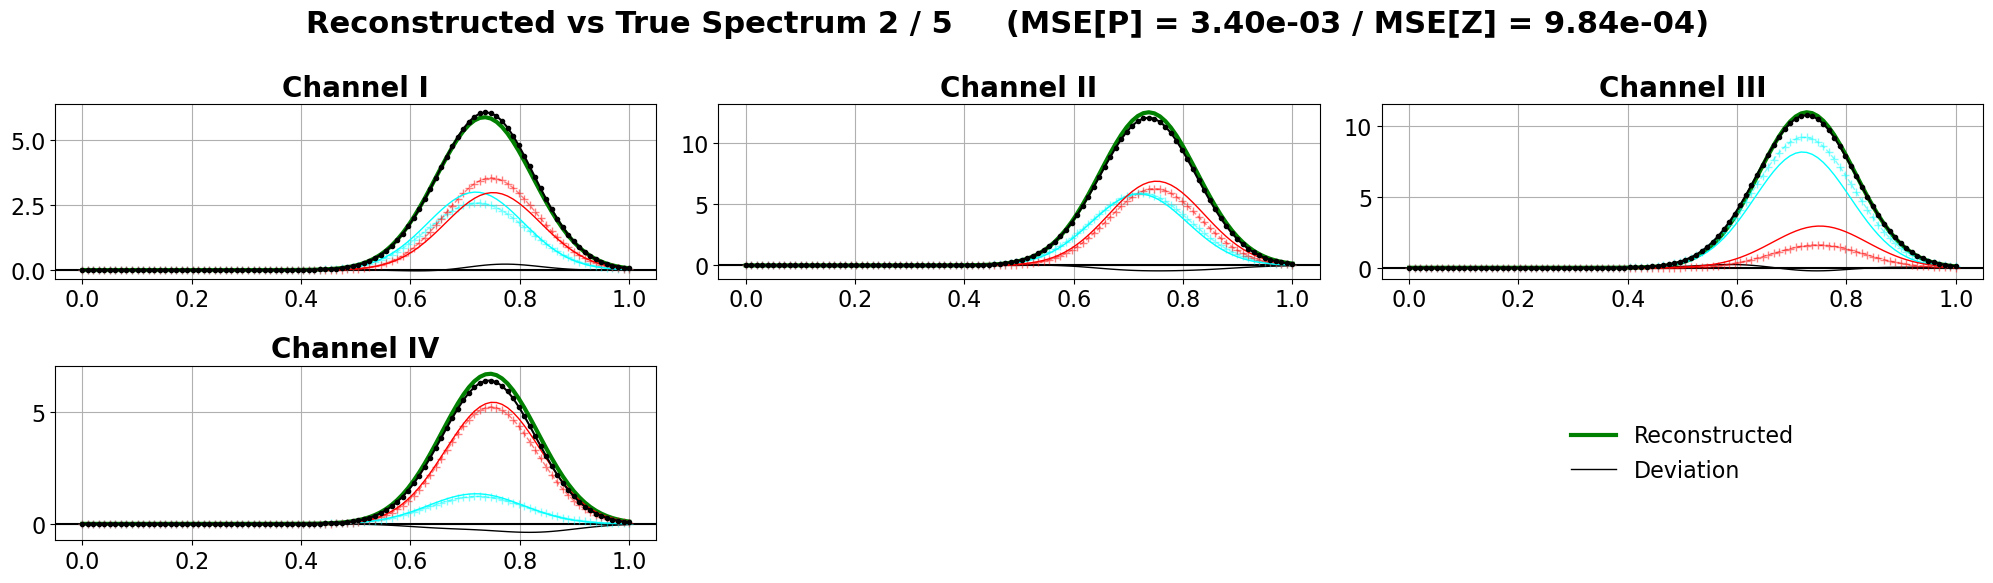

Reconstructed vs True Spectrum 3 / 5     (MSE[P] = 5.17e-04 / MSE[Z] = 1.02e-02)
* Velocities:
    Pred: [tensor(-0.2688, device='cuda:0'), tensor(0.0771, device='cuda:0')]
    True: [tensor(-0.2677, device='cuda:0'), tensor(0.0666, device='cuda:0')]
* Dispersion:
    Pred: [tensor(0.0090, device='cuda:0'), tensor(0.0234, device='cuda:0')]
    True: [tensor(0.0111, device='cuda:0'), tensor(0.0230, device='cuda:0')]
* Amplitudes:
    Line I.A:
      Pred [tensor(3.5157, device='cuda:0'), tensor(8.3744, device='cuda:0')],
      True [tensor(3.4554, device='cuda:0'), tensor(8.9263, device='cuda:0')],
    Line II.A:
      Pred [tensor(0.9198, device='cuda:0'), tensor(9.6118, device='cuda:0')],
      True [tensor(0.6036, device='cuda:0'), tensor(9.7533, device='cuda:0')],
    Line III.A:
      Pred [tensor(7.6519, device='cuda:0'), tensor(2.6085, device='cuda:0')],
      True [tensor(7.8440, device='cuda:0'), tensor(2.7253, device='cuda:0')],
    Line IV.A:
      Pred [tensor(3.6688, device

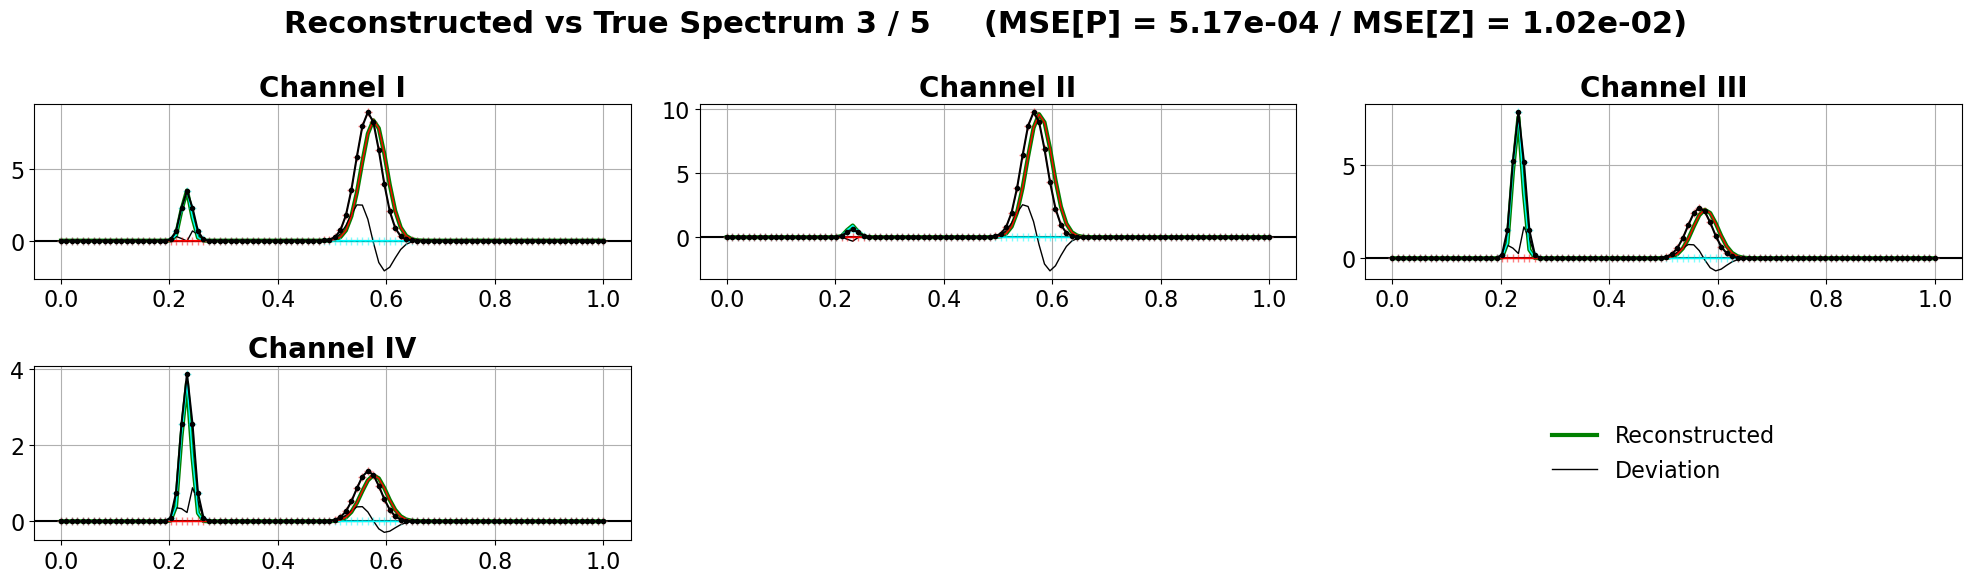

Reconstructed vs True Spectrum 4 / 5     (MSE[P] = 2.04e-04 / MSE[Z] = 1.70e-03)
* Velocities:
    Pred: [tensor(-0.2111, device='cuda:0'), tensor(0.2416, device='cuda:0')]
    True: [tensor(-0.2055, device='cuda:0'), tensor(0.2454, device='cuda:0')]
* Dispersion:
    Pred: [tensor(0.0641, device='cuda:0'), tensor(0.0327, device='cuda:0')]
    True: [tensor(0.0650, device='cuda:0'), tensor(0.0304, device='cuda:0')]
* Amplitudes:
    Line I.A:
      Pred [tensor(3.0547, device='cuda:0'), tensor(7.2969, device='cuda:0')],
      True [tensor(3.0191, device='cuda:0'), tensor(7.4433, device='cuda:0')],
    Line II.A:
      Pred [tensor(2.4123, device='cuda:0'), tensor(7.8575, device='cuda:0')],
      True [tensor(2.4469, device='cuda:0'), tensor(7.7760, device='cuda:0')],
    Line III.A:
      Pred [tensor(3.9678, device='cuda:0'), tensor(2.1316, device='cuda:0')],
      True [tensor(4.2376, device='cuda:0'), tensor(2.1080, device='cuda:0')],
    Line IV.A:
      Pred [tensor(4.9573, device

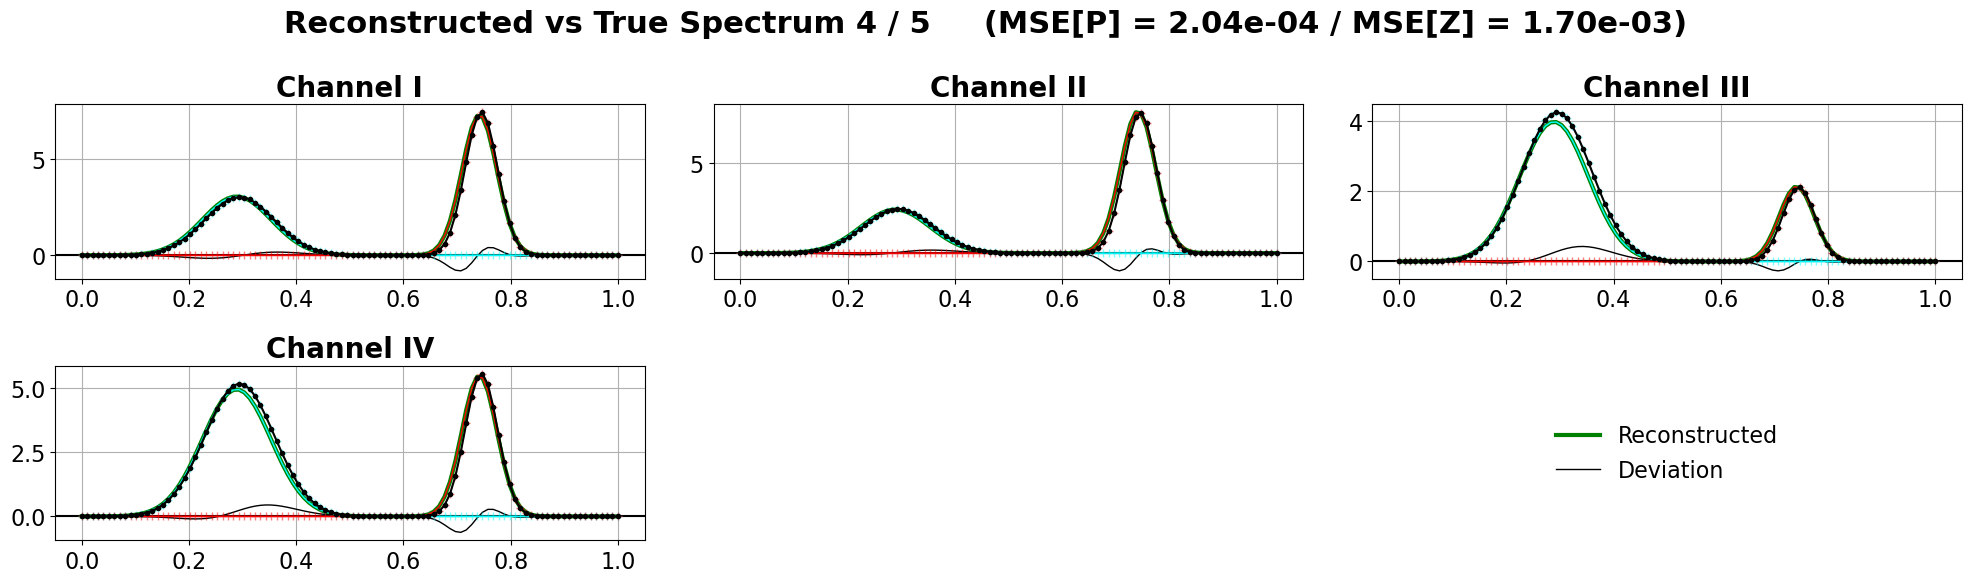

Reconstructed vs True Spectrum 5 / 5     (MSE[P] = 8.77e-05 / MSE[Z] = 6.34e-04)
* Velocities:
    Pred: [tensor(-0.1176, device='cuda:0'), tensor(0.1766, device='cuda:0')]
    True: [tensor(-0.1243, device='cuda:0'), tensor(0.1748, device='cuda:0')]
* Dispersion:
    Pred: [tensor(0.0885, device='cuda:0'), tensor(0.0375, device='cuda:0')]
    True: [tensor(0.0883, device='cuda:0'), tensor(0.0378, device='cuda:0')]
* Amplitudes:
    Line I.A:
      Pred [tensor(2.1609, device='cuda:0'), tensor(8.0244, device='cuda:0')],
      True [tensor(2.1765, device='cuda:0'), tensor(8.0929, device='cuda:0')],
    Line II.A:
      Pred [tensor(4.6044, device='cuda:0'), tensor(4.8816, device='cuda:0')],
      True [tensor(4.7839, device='cuda:0'), tensor(4.8024, device='cuda:0')],
    Line III.A:
      Pred [tensor(5.0871, device='cuda:0'), tensor(7.5036, device='cuda:0')],
      True [tensor(5.1873, device='cuda:0'), tensor(7.6088, device='cuda:0')],
    Line IV.A:
      Pred [tensor(3.2155, device

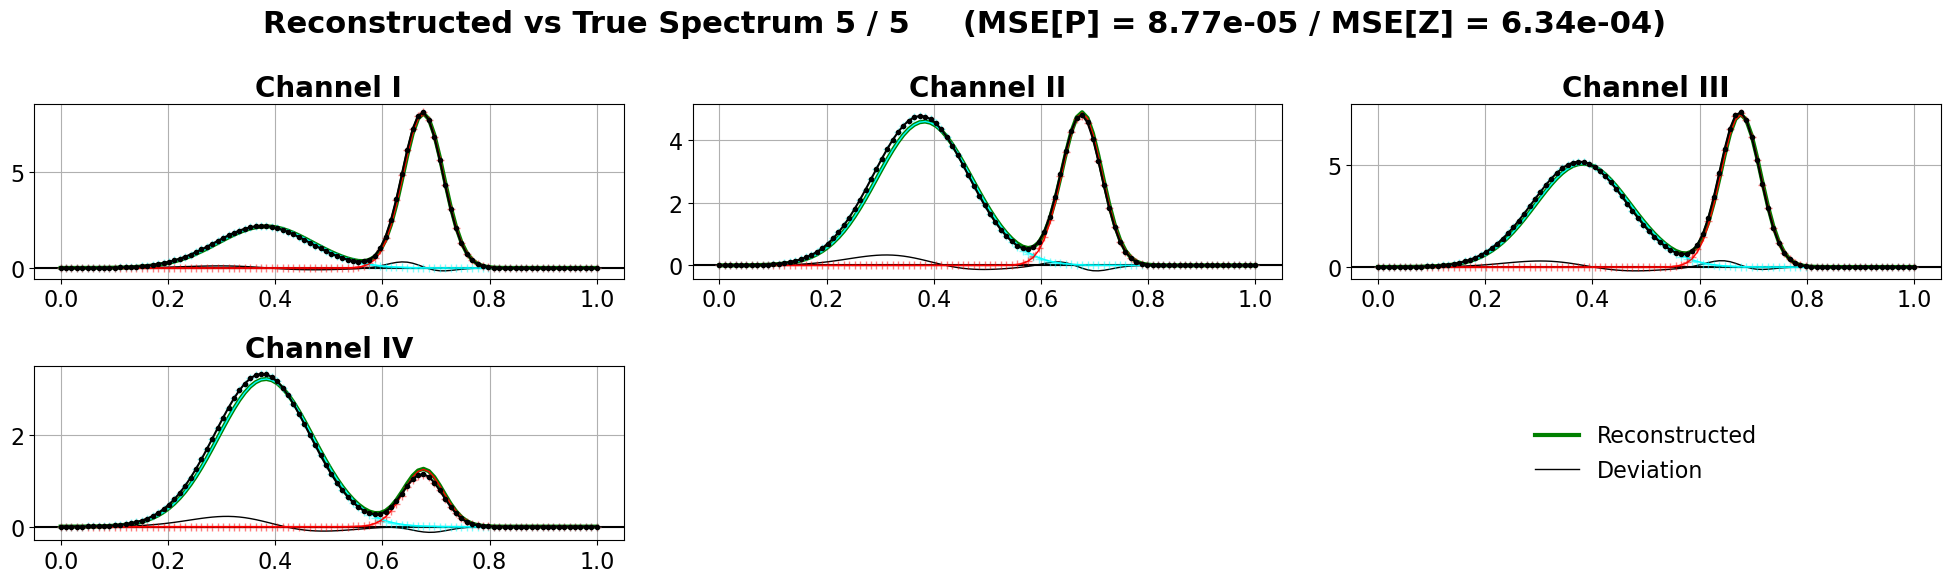

In [11]:
from parameters import Pattern

# Choose a sample from the train or test data
# signal, params = next(iter(train_loader))
signal, targets = next(iter(test_loader))

## Phase 1. Get network prediction
with torch.no_grad():
  model.eval()
  output = model(signal)
  
## Phase 2. Optimize output parameters to better fit data

# Create a tensor mask which selects amplitude parameters in network outputs
amp_mask = parameter_mapping.pack_tensor(param_dict={
    key : torch.tensor([int(Pattern.match(key, (None, 'amp', None)))], dtype=torch.float64, device=device) # False / True => 0 / 1 
      for (key, val) in par_dict.items()
})

# L2 Regularization of negative amplitudes
amp_reg = lambda out : negative_l2_reg(out, amp_mask, weight=1e-5)

# output = gaussian_model.fit(x, output, signal, 
#                              lr=1e-2, 
#                              nsteps=250, 
#                              reg=None,
#                              verbose=True
#                              )

# Extract Gaussians from the outputs and reconstruct predicted spectrum
y_pred = gaussian_model.components(x, output)
z_pred = gaussian_model(x, output)

# Extract Gaussians from the targets and reconstruct ground truth spectrum
y_true = gaussian_model.components(x, targets)
z_true = gaussian_model(x, targets) # No 

loss = {
  'param': parameter_loss(output, targets, reduction='none'), # targets.shape = (N, P)
  'signal': signal_loss(output, targets, x, reduction='none') # z.shape = (N, C, D)
}

# Compute params
p_pred = parameter_mapping.unpack_tensor(output)
p_true = parameter_mapping.unpack_tensor(targets)

# Convert to numpy
y_true = y_true.cpu().numpy()
z_true = z_true.cpu().numpy()
y_pred = y_pred.cpu().numpy()
z_pred = z_pred.cpu().numpy()
loss = {k: v.cpu().numpy() for k, v in loss.items()}

# Plotting
plot_sample_count = 5
legends = {}
for sample in range(0, plot_sample_count):

  print(f'Reconstructed vs True Spectrum {sample+1} / {5}     (MSE[P] = {loss['param'][sample]:.2e} / MSE[Z] = {loss['signal'][sample]:.2e})')
  print('* Velocities:', 
        f'    Pred: {[p_pred['velocity', c][sample] for c in (0, 1)]}',
        f'    True: {[p_true['velocity', c][sample] for c in (0, 1)]}',
        sep='\n')
  print('* Dispersion:', 
        f'    Pred: {[p_pred['dispersion', c][sample] for c in (0, 1)]}',
        f'    True: {[p_true['dispersion', c][sample] for c in (0, 1)]}',
        sep='\n')
  print('* Amplitudes:', 
        *(
            f'    Line {ln}:\n' 
            f'      Pred {[p_pred[ln, 'amp', c][sample] for c in (0, 1)]},\n' 
            f'      True {[p_true[ln, 'amp', c][sample] for c in (0, 1)]},' 
          for i, ln in enumerate(emlines)
        ), 
        sep='\n')  

  plt.figure(figsize=(20, 6))
  plt.suptitle(f'Reconstructed vs True Spectrum {sample+1} / {5}     (MSE[P] = {loss['param'][sample]:.2e} / MSE[Z] = {loss['signal'][sample]:.2e})')
  for ch_idx, ch in enumerate(channels.values()):
    
    x_ch = x[0, ch_idx].cpu().numpy()

    ax = plt.subplot((C+2)//3, 3, ch_idx+1)
    ax.set_title(f'Channel {ch.name}')
    ax.errorbar(x_ch, z_true[sample, ch_idx], yerr=w_std[sample, ch_idx], color='black', marker='.')
    # ax.plot(x_ch, z_true[sample, ch_idx], label='Input Spectrum', color='black', marker='o')
    ax.axhline(0, 0, 1, color='black', linestyle='solid')
    ax.plot(x_ch, z_pred[sample, ch_idx], label='Reconstructed', color='green', linestyle='solid', linewidth=3)
    ax.plot(x_ch, z_true[sample, ch_idx] - z_pred[sample, ch_idx], label='Deviation', color='black', linestyle='solid', linewidth=1)

    for line_idx, line_name in enumerate(ch.lines):
      for comp_idx, color in zip(range(GpL), ['cyan', 'red']):
        ax.plot(x_ch, y_true[sample, ch_idx, line_idx, comp_idx], linestyle='dashed', marker='+', color=color, alpha=0.5, linewidth=1)
      for comp_idx, color in zip(range(GpL), ['cyan', 'red']):
        ax.plot(x_ch, y_pred[sample, ch_idx, line_idx, comp_idx], linestyle='solid', color=color, linewidth=1)

     # Collect legend handles and labels from subplot
    handles, labels = ax.get_legend_handles_labels()
    for h, l in zip(handles, labels):
      if l not in legends:
          legends[l] = h

    ax.grid(True)

  # Replace final axis by legend
  legend_ax = plt.subplot((C+2)//3, 3, 6)
  legend_ax.axis('off')  # Hide the axes  
  legend_ax.legend(handles, labels, loc='center', frameon=False) # Add the legend to the new axes

  # plt.text(0.99, 0.95, f'MSE[P] = {loss['param'][sample]:.2e} / MSE[Z] = {loss['signal'][sample]:.2e}', horizontalalignment='right', verticalalignment='top', transform=plt.gca().transAxes)
  
  # plt.xlabel('x')
  # plt.ylabel('y')
  plt.tight_layout()
  plt.show()